# Task 1 — Plots

In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "--quiet"])
import pandas as pd, matplotlib.pyplot as plt, glob

def load(folder):
    files = glob.glob(f"{folder}/part-*.csv")
    if not files:
        files = glob.glob(f"{folder}/*.csv")
    return pd.concat([pd.read_csv(f, header=0) for f in files], ignore_index=True)

BASE = "/home/jovyan/python/task1_out"
print("Files found in q3_daily:", len(glob.glob(f"{BASE}/q3_daily/*.csv")))


Files found in q3_daily: 1


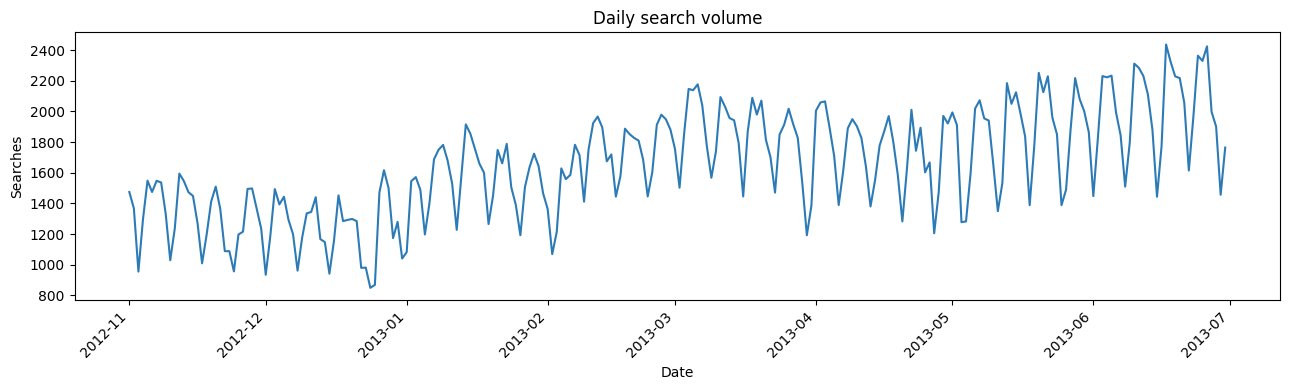

        date  impressions  searches  clicks  bookings     ctr  conv_rate
0 2012-11-01        35986      1474    1642      1036  0.0456     0.0288
1 2012-11-02        33710      1367    1505       978  0.0446     0.0290
2 2012-11-03        23219       955    1068       649  0.0460     0.0280
3 2012-11-04        32437      1295    1442       895  0.0445     0.0276
4 2012-11-05        37933      1548    1717      1073  0.0453     0.0283
5 2012-11-06        36905      1474    1603      1017  0.0434     0.0276
6 2012-11-07        38446      1547    1697      1106  0.0441     0.0288
7 2012-11-08        38365      1536    1731      1062  0.0451     0.0277
8 2012-11-09        33241      1332    1513       973  0.0455     0.0293
9 2012-11-10        25903      1029    1161       716  0.0448     0.0276


In [2]:
q3 = load(f"{BASE}/q3_daily")
q3.columns = ["date","impressions","searches","clicks","bookings","ctr","conv_rate"]
q3["date"] = pd.to_datetime(q3["date"])
q3 = q3.sort_values("date")

fig, ax = plt.subplots(figsize=(13,4))
ax.plot(q3["date"], q3["searches"], color="#2c7bb6", linewidth=1.5)
ax.set_title("Daily search volume"); ax.set_xlabel("Date"); ax.set_ylabel("Searches")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig("q3_searches.png", dpi=150); plt.show()
print(q3.head(10).to_string())


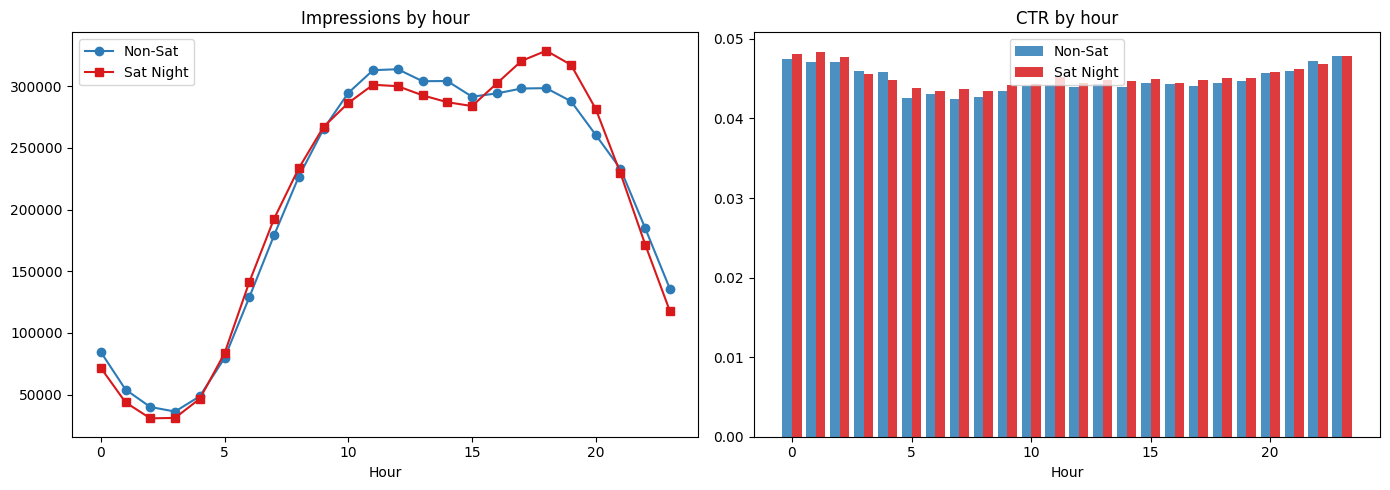

In [3]:
q4 = load(f"{BASE}/q4_tod")
q4.columns = ["hour","sat","impressions","ctr"]
sat   = q4[q4["sat"]==1]; other = q4[q4["sat"]==0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(other["hour"], other["impressions"], label="Non-Sat", marker="o", color="#2c7bb6")
ax1.plot(sat["hour"],   sat["impressions"],   label="Sat Night", marker="s", color="#d7191c")
ax1.set_title("Impressions by hour"); ax1.set_xlabel("Hour"); ax1.legend()

w = 0.4
ax2.bar(other["hour"]-w/2, other["ctr"], width=w, label="Non-Sat",   color="#2c7bb6", alpha=0.85)
ax2.bar(sat["hour"]+w/2,   sat["ctr"],   width=w, label="Sat Night", color="#d7191c", alpha=0.85)
ax2.set_title("CTR by hour"); ax2.set_xlabel("Hour"); ax2.legend()
plt.tight_layout(); plt.savefig("q4_tod.png", dpi=150); plt.show()


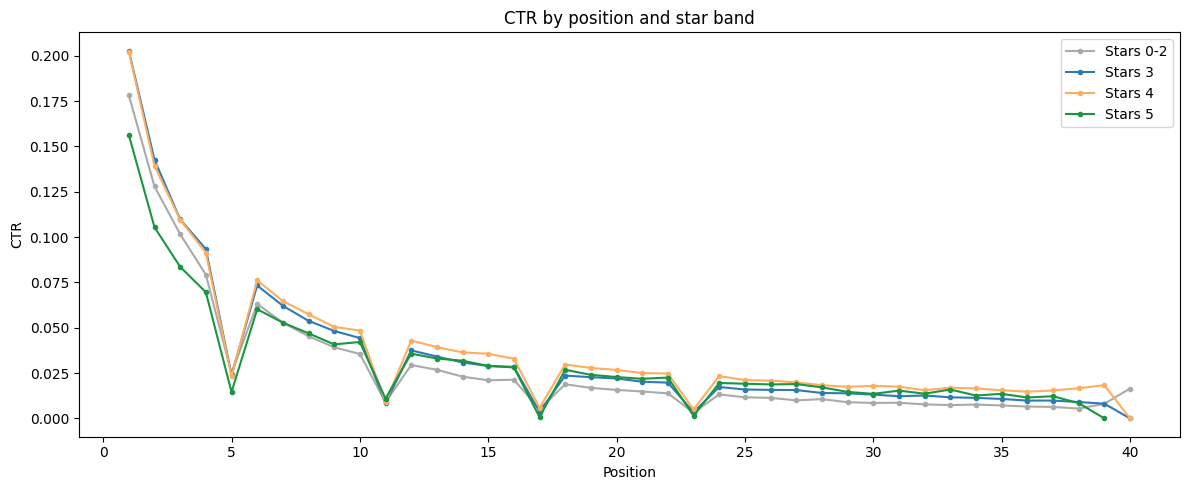

In [4]:
q5 = load(f"{BASE}/q5_position")
q5.columns = ["position","star_band","clicks","ctr","conv_rate"]

colors = {"0-2":"#aaaaaa","3":"#2c7bb6","4":"#fdae61","5":"#1a9641"}
fig, ax = plt.subplots(figsize=(12,5))
for band, grp in q5.groupby("star_band"):
    ax.plot(grp["position"], grp["ctr"], label=f"Stars {band}",
            marker=".", color=colors.get(str(band),"grey"))
ax.set_title("CTR by position and star band")
ax.set_xlabel("Position"); ax.set_ylabel("CTR"); ax.legend()
plt.tight_layout(); plt.savefig("q5_position.png", dpi=150); plt.show()


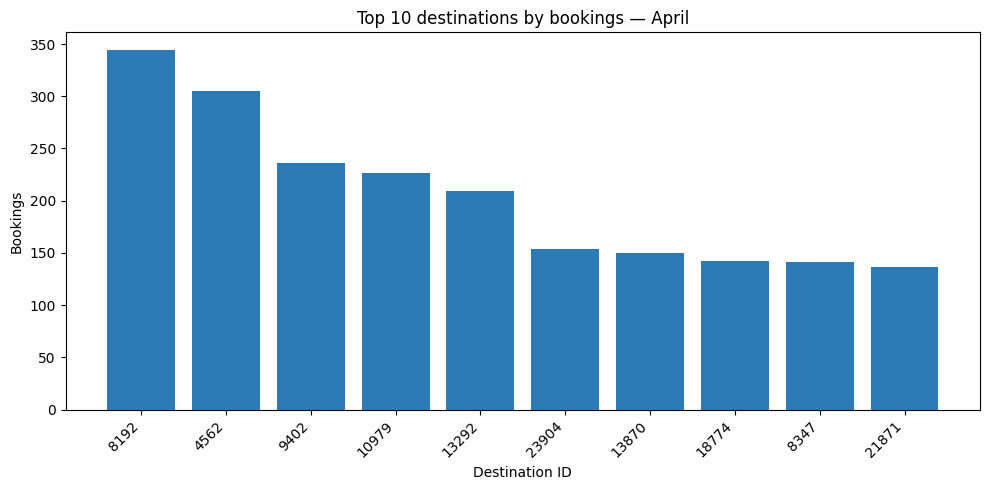

In [5]:
q6 = load(f"{BASE}/q6_top_bookings")
q6.columns = ["month","dest_id","impressions","bookings","conv_rate"]
q6m = q6[q6["month"]==4].sort_values("bookings", ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(q6m["dest_id"].astype(str), q6m["bookings"], color="#2c7bb6")
ax.set_title("Top 10 destinations by bookings — April")
ax.set_xlabel("Destination ID"); ax.set_ylabel("Bookings")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig("q6_destinations.png", dpi=150); plt.show()


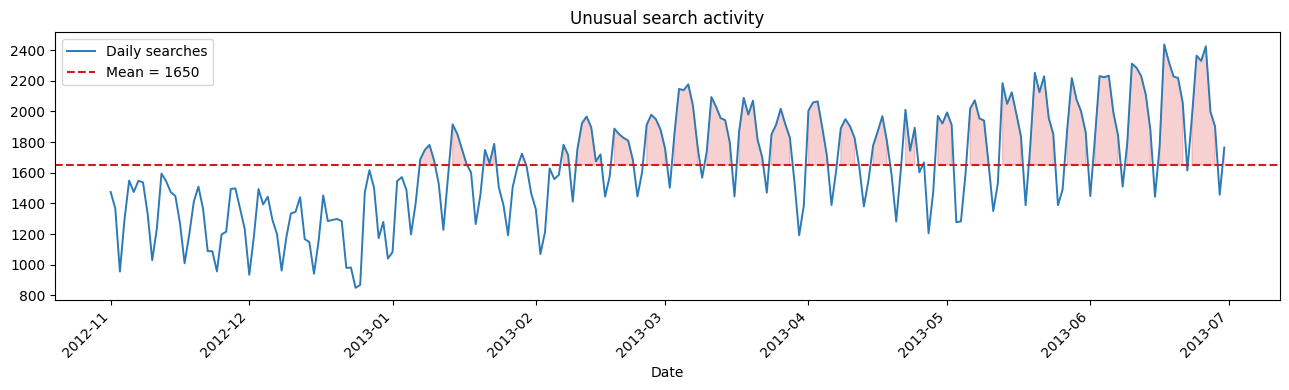

          date  searches
228 2013-06-17      2436
237 2013-06-26      2424
235 2013-06-24      2363
236 2013-06-25      2329
229 2013-06-18      2323
221 2013-06-10      2311
222 2013-06-11      2284
200 2013-05-20      2251
216 2013-06-05      2233
223 2013-06-12      2231
214 2013-06-03      2230
202 2013-05-22      2229
230 2013-06-19      2228
215 2013-06-04      2222
231 2013-06-20      2217
208 2013-05-28      2217
193 2013-05-13      2184
125 2013-03-06      2176
123 2013-03-04      2146
124 2013-03-05      2138
201 2013-05-21      2125
195 2013-05-15      2124
224 2013-06-13      2110
130 2013-03-11      2093
137 2013-03-18      2088
209 2013-05-29      2079
187 2013-05-07      2072
139 2013-03-20      2070
153 2013-04-03      2065
152 2013-04-02      2058
232 2013-06-21      2056
194 2013-05-14      2049
126 2013-03-07      2039
131 2013-03-12      2031
186 2013-05-06      2018
145 2013-03-26      2017
172 2013-04-22      2010
151 2013-04-01      2004
210 2013-05-30      2000


In [6]:
q7 = load(f"{BASE}/q7_daily")
q7.columns = ["date","searches"]
q7["date"] = pd.to_datetime(q7["date"]); q7 = q7.sort_values("date")
mean_val = q7["searches"].mean()

fig, ax = plt.subplots(figsize=(13,4))
ax.plot(q7["date"], q7["searches"], color="#2c7bb6", linewidth=1.4, label="Daily searches")
ax.axhline(mean_val, color="#d7191c", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_val:.0f}")
ax.fill_between(q7["date"], q7["searches"], mean_val,
                where=q7["searches"]>mean_val, alpha=0.2, color="#d7191c")
ax.legend(); ax.set_title("Unusual search activity"); ax.set_xlabel("Date")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig("q7_unusual.png", dpi=150); plt.show()

unusual = q7[q7["searches"] > mean_val].sort_values("searches", ascending=False)
print(unusual.to_string())
